This is a test notebook for messing around with. Hopefully good notes and ideas flow from here.

Look at flow of traffic congestion and real time forecasting of the average wait and stop and go patterns of the cars.

Maybe learn vs code..

In [1]:
'''
This is a docstring for practice
'''

'\nThis is a docstring for practice\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump, load
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go
import plotly.tools as tls
import plotly.offline as py
import matplotlib.ticker as ticker
from matplotlib import animation
from datetime import datetime, timedelta
from shapely.geometry import Point

In [3]:
stop_times = pd.read_csv('../data/google_transit/stop_times.csv')

In [4]:
print(stop_times.loc[stop_times['pickup_type'] == 1].head(10))

      trip_id arrival_time departure_time stop_id  stop_sequence  \
4158   347773      6:39:00        6:39:00    HBHS             29   
4187   347774      9:41:00        9:41:00    HBHS             29   
4216   347775     10:11:00       10:11:00    HBHS             29   
4245   347776     10:43:00       10:43:00    HBHS             29   
4274   347777     11:13:00       11:13:00    HBHS             29   
4303   347778     11:43:00       11:43:00    HBHS             29   
4332   347779     12:13:00       12:13:00    HBHS             29   
4361   347780     12:43:00       12:43:00    HBHS             29   
4390   347781     13:13:00       13:13:00    HBHS             29   
4419   347782     13:43:00       13:43:00    HBHS             29   

      stop_headsign  pickup_type  drop_off_type  shape_dist_traveled  \
4158            NaN            1              0              10.2932   
4187            NaN            1              0              10.2932   
4216            NaN            1   

In [5]:
transit_centers = pd.read_csv('../data/transit_centers.csv')

In [6]:
transit_centers_trunc = transit_centers[['Element', "Lat", 'Long']].copy()

In [7]:
routes = pd.read_csv('../data/google_transit/routes.txt')

In [8]:
stops = pd.read_csv('../data/google_transit/stops.txt')

In [9]:
shapes = pd.read_csv('../data/google_transit/shapes.txt')

In [10]:
trips = pd.read_csv('../data/google_transit/trips.txt')

In [11]:
calendar = pd.read_csv('../data/google_transit/calendar.txt')

In [12]:
calendar_dates = pd.read_csv('../data/google_transit/calendar_dates.txt')

In [13]:
all_years_aadt_total = pd.read_csv('../data/aadt_SUM_all_years.csv')

''

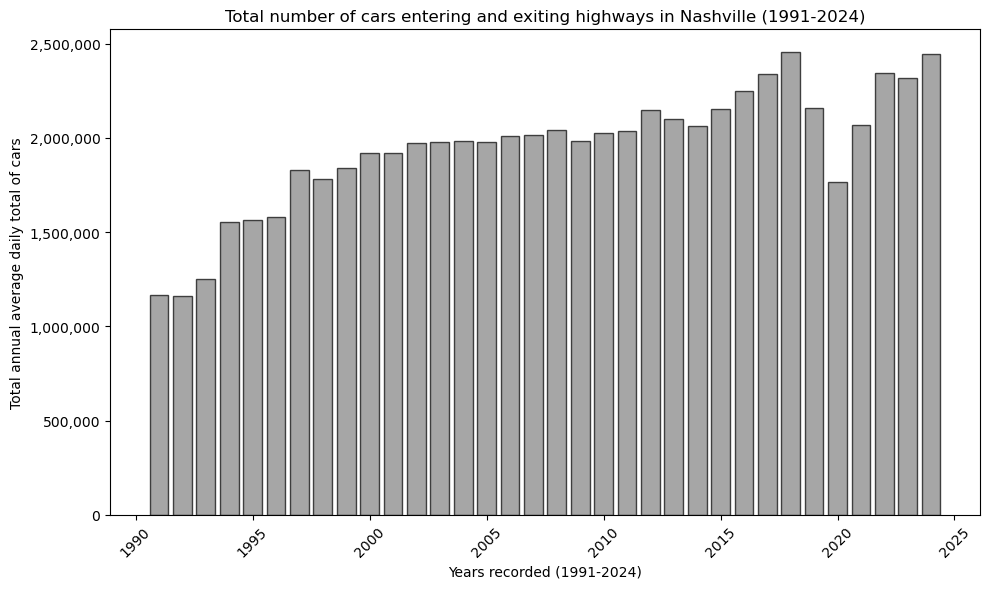

In [14]:
'''
Plot showing the sum of the annual average daily total of cars entering and exiting the highways of Nashville between 1991 and 2024.
This bar graph shows the change in the number of cars over the years, indicating trends in traffic volume. The total is in millions.
'''
plt.figure(figsize=(10, 6))
plt.bar(all_years_aadt_total['AADT_YEAR'], all_years_aadt_total['sum'], edgecolor='black', facecolor='grey', alpha=0.7)

plt.xlabel('Years recorded (1991-2024)')
plt.ylabel('Total annual average daily total of cars')
plt.xticks(rotation=45)
plt.title('Total number of cars entering and exiting highways in Nashville (1991-2024)')

def y_format(x, pos):
    return f"{int(x):,}"

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(y_format))

plt.tight_layout()

# plt.savefig('../images/aadt_total_cars_nashville.png', dpi=600)
;   

In [15]:
streets_gdf = gpd.read_file('../data/Street_Centerlines_view.gpkg')

streets_gdf = streets_gdf['geometry'].to_crs(epsg=4326)

c:\Users\cavin\miniforge3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column LAST_PAVED, 1995-08-01T00:00:00.0Z, successfully parsed



In [16]:
railroads = gpd.read_file('../data/railroad.gpkg')
railroads = railroads['geometry'].to_crs(epsg=4326) 

c:\Users\cavin\miniforge3\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column Mod_Date, 2018-12-11T00:00:00.0Z, successfully parsed



In [17]:
transit_centers_gdf = gpd.GeoDataFrame(transit_centers, geometry=gpd.points_from_xy(transit_centers['Long'], transit_centers['Lat']))
transit_centers_gdf.crs = 'EPSG:4326'  # Set the coordinate reference system

In [18]:
stops_gdf = gpd.GeoDataFrame(stops, geometry=gpd.points_from_xy(stops['stop_lon'], stops['stop_lat']))
stops_gdf.crs = 'EPSG:4326'  # Set the coordinate reference system

In [19]:
# Create a buffer (e.g., 500 meters) around the first transit center
buffer = transit_centers_gdf.geometry.iloc[2].buffer(0.260)  # ~0.005 degrees is roughly 500m, adjust as needed

# Filter stops within the buffer
gdf_within_boundary = stops_gdf[stops_gdf.geometry.within(buffer)]

# Filter stops that intersect the buffer
gdf_intersecting_boundary = stops_gdf[stops_gdf.geometry.intersects(buffer)]

# Clip stops to the buffer (returns only the part of geometry within the buffer, but for points it's just a filter)
stops_gdf_clipped = stops_gdf[stops_gdf.geometry.within(buffer)]

In [20]:
# Create a buffer (e.g., 500 meters) around the first transit center
rail_road_buffer = transit_centers_gdf.geometry.iloc[2].buffer(0.310)  # ~0.005 degrees is roughly 500m, adjust as needed

# Filter stops within the buffer
railroad_within_boundary = railroads[railroads.geometry.within(rail_road_buffer)]

# Filter stops that intersect the buffer
railroad_intersecting_boundary = railroads[railroads.geometry.intersects(rail_road_buffer)]

# Clip stops to the buffer (returns only the part of geometry within the buffer, but for points it's just a filter)
railroad_gdf_clipped = railroads[railroads.geometry.within(rail_road_buffer)]

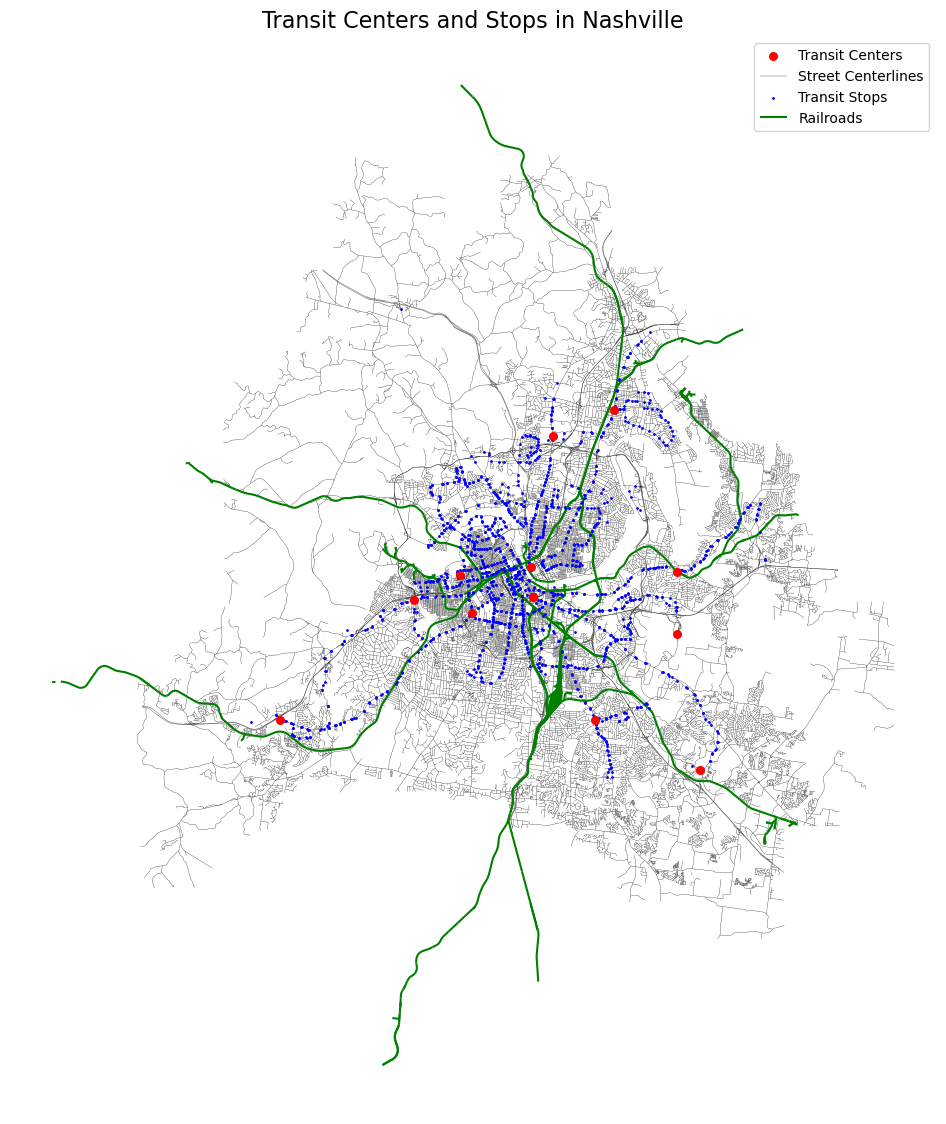

In [21]:
fig, ax = plt.subplots(figsize=(14, 14))

base = transit_centers_gdf.plot(ax=ax, color='red', markersize=30, zorder=2,label='Transit Centers')

streets_gdf.plot(ax=base, edgecolor='black', zorder=0, linewidth=0.2, label='Street Centerlines')

stops_gdf_clipped.plot(ax=base, color='blue', markersize=1, zorder=1, label='Transit Stops')

railroad_gdf_clipped.plot(ax=base, edgecolor='green', zorder=0, linewidth=1.5, label='Railroads')

ax.set_title('Transit Centers and Stops in Nashville', fontsize=16)
ax.set_axis_off()
ax.set_facecolor('none')
fig.patch.set_facecolor('none')
plt.legend()
plt.show()
#plt.savefig('../images/transit_centers_and_stops_nashville.png', bbox_inches='tight', dpi=600)

In [22]:
stop_times_trunc = stop_times[['stop_id', 'trip_id','stop_sequence', 'arrival_time', 'departure_time', 'shape_dist_traveled']].copy()

In [23]:
stops_trunc = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'parent_station']].copy()

In [24]:
stops_df = stop_times_trunc.merge(stops_trunc, on='stop_id', how='left')

In [25]:
# stops_df.to_csv('../data/stops_df.csv', index=False)

In [26]:
all_boardings = pd.read_csv('../data/2023e_shapefile/all_boardings.csv')

In [27]:
print(all_boardings.head(10))

  Route-Stop         ON       OFF  Route_ID  Route_Name  Stop_ID  Node_ID
0        1-1  578.52100   0.00000         1         NaN        1  2100535
1       1-10    8.40686  11.55800         1         NaN       10  2100652
2       1-11    5.25000  16.54480         1         NaN       11  2100655
3       1-12    3.22917  13.61340         1         NaN       12  2100656
4       1-13   11.47450  25.87590         1         NaN       13  2100657
5       1-14    0.00000   0.50000         1         NaN       14  2118288
6       1-15    5.04167   9.99997         1         NaN       15  2118309
7       1-16    2.50000  13.43510         1         NaN       16  2118120
8       1-17    3.66856   5.33662         1         NaN       17  2102904
9       1-18    4.52083  33.20770         1         NaN       18  2118265


In [28]:
assignment_result = pd.read_csv('../data/2023e_shapefile/assignment_result.csv')

In [29]:
assignment_result[['NAME', 'Leng', 'VOL_PASS', 'SPD_AMAB']]

,NAME,Leng,VOL_PASS,SPD_AMAB
0,PASQUO RD.,0.234764,4374.010,30.8251
1,UNION BRIDGE RD.,0.009707,4374.010,30.8251
2,UNION BRIDGE RD.,0.170260,4374.010,30.8251
3,UNION BRIDGE RD.,0.097003,5379.960,27.0459
4,MCCRORY LN.,0.163211,3851.430,34.7842
...,...,...,...,...
38720,Centroid Connector,0.536202,1547.850,30.0000
38721,Centroid Connector,0.122017,6944.380,30.0000
38722,RAMP,0.425855,4345.110,11.5870
38723,RAMP,0.486524,440.883,29.0916


In [30]:
list(assignment_result.columns)

['ID',
 'CNT',
 'FCLASS',
 'NAME',
 'Leng',
 'VOL_TOT',
 'VOL_AB',
 'VOL_BA',
 'VOL_AM',
 'VOL_AMAB',
 'VOL_AMBA',
 'VOL_MD',
 'VOL_MDAB',
 'VOL_MDBA',
 'VOL_PM',
 'VOL_PMAB',
 'VOL_PMBA',
 'VOL_OP',
 'VOL_OPAB',
 'VOL_OPBA',
 'VOL_PASS',
 'VOL_PASSAB',
 'VOL_PASSBA',
 'VOL_PASSAM',
 'VOL_PASSAMAB',
 'VOL_PASSAMBA',
 'VOL_PASSMD',
 'VOL_PASSMDAB',
 'VOL_PASSMDBA',
 'VOL_PASSPM',
 'VOL_PASSPMAB',
 'VOL_PASSPMBA',
 'VOL_PASSOP',
 'VOL_PASSOPAB',
 'VOL_PASSOPBA',
 'VOL_HOV2',
 'VOL_HOV2AB',
 'VOL_HOV2BA',
 'VOL_HOV2AM',
 'VOL_HOV2AMAB',
 'VOL_HOV2AMBA',
 'VOL_HOV2MD',
 'VOL_HOV2MDAB',
 'VOL_HOV2MDBA',
 'VOL_HOV2PM',
 'VOL_HOV2PMAB',
 'VOL_HOV2PMBA',
 'VOL_HOV2OP',
 'VOL_HOV2OPAB',
 'VOL_HOV2OPBA',
 'VOL_HOV3',
 'VOL_HOV3AB',
 'VOL_HOV3BA',
 'VOL_HOV3AM',
 'VOL_HOV3AMAB',
 'VOL_HOV3AMBA',
 'VOL_HOV3MD',
 'VOL_HOV3MDAB',
 'VOL_HOV3MDBA',
 'VOL_HOV3PM',
 'VOL_HOV3PMAB',
 'VOL_HOV3PMBA',
 'VOL_HOV3OP',
 'VOL_HOV3OPAB',
 'VOL_HOV3OPBA',
 'VOL_COM',
 'VOL_COMAB',
 'VOL_COMBA',
 'VOL_COMAM',
 'V

In [31]:
print(assignment_result.head(10))

     ID      CNT  FCLASS              NAME      Leng  VOL_TOT   VOL_AB  \
0  2610  47037.0    17.0        PASQUO RD.  0.234764  5086.44  2523.86   
1  2611  47037.0    17.0  UNION BRIDGE RD.  0.009707  5086.44  2523.86   
2  2612  47037.0    17.0  UNION BRIDGE RD.  0.170260  5086.44  2523.86   
3  2613  47037.0    17.0  UNION BRIDGE RD.  0.097003  6275.40  3110.92   
4  2614  47037.0    17.0       MCCRORY LN.  0.163211  6124.16  3291.34   
5  2615  47037.0    17.0       MCCRORY LN.  0.081625  6124.16  3291.34   
6  2616  47037.0    17.0       MCCRORY LN.  0.127611  6124.16  3291.34   
7  2617  47037.0    17.0       MCCRORY LN.  0.329571  6044.00  3335.51   
8  2618  47037.0    17.0       MCCRORY LN.  0.105058  6029.58  3329.56   
9  2619  47037.0    17.0       MCCRORY LN.  0.448096  6029.58  3329.56   

    VOL_BA   VOL_AM  VOL_AMAB  ...  Pct_FF_OP  MU_VHT_AMAB  MU_VHT_AMBA  \
0  2562.58  1753.39   993.142  ...   0.999953     0.194873     0.193065   
1  2562.58  1753.39   993.142  ... 

In [32]:
full_traffic_data = pd.read_csv('../data/full_traffic_data.csv')

In [33]:
print(full_traffic_data.head(10))

      LOCAL_ID    DIR  LATITUDE  LONGITUDE                  AT_ROAD  \
0     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
1  19000153_EB     EB  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
2  19000153_EB     EB  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
3  19000153_EB     EB  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
4  19000153_EB     EB  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
5     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
6     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
7     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
8     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   
9     19000153  2-WAY  36.17333 -86.764056  NEAR WOODLAND ST BRIDGE   

  ON_ROAD_ALIAS  H01_1  H01_2  H01_3  H01_4  ...  H23_2  H23_3  H23_4  H24_1  \
0      MAIN ST.   59.0   45.0   49.0   37.0  ...  122.0  113.0   78.0   70.0   
1      MAIN ST.   27.0   27.0   25.0   18.0  ...   52.0   

In [34]:
full_traffic_data[full_traffic_data['ON_ROAD_ALIAS'].str.contains('CHARLOTTE PK', na=False)].dropna()

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE,AADT
5014,19000465_EB,EB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,12.0,7.0,8.0,7.0,...,30.0,39.0,34.0,24.0,25.0,21.0,23.0,2003-01-22 00:00:00,2003-01-23 00:00:00,11017.0
5015,19000465_WB,WB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,22.0,21.0,20.0,13.0,...,35.0,51.0,38.0,44.0,44.0,37.0,34.0,2003-01-22 00:00:00,2003-01-23 00:00:00,12193.0
5016,19000465_EB,EB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,12.0,7.0,8.0,7.0,...,30.0,39.0,34.0,24.0,25.0,21.0,23.0,2003-01-22 00:00:00,2003-01-23 00:00:00,11556.0
5017,19000465_WB,WB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,22.0,21.0,20.0,13.0,...,35.0,51.0,38.0,44.0,44.0,37.0,34.0,2003-01-22 00:00:00,2003-01-23 00:00:00,11610.0
6724,19000119,2-WAY,36.096682,-86.968617,NEAR SR-1,CHARLOTTE PK.,2.0,2.0,6.0,1.0,...,23.0,6.0,11.0,7.0,5.0,4.0,3.0,2003-01-29 00:00:00,2003-01-30 00:00:00,4034.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1850906,19000584,2-WAY,36.121317,-86.920561,OLD CHARLOTTE PIKE,OLD CHARLOTTE PK.,0.0,0.0,0.0,0.0,...,2.0,3.0,0.0,5.0,5.0,6.0,1.0,2024-10-03 00:00:00,2024-10-04 00:00:00,805.0
1850907,19000584,2-WAY,36.121317,-86.920561,OLD CHARLOTTE PIKE,OLD CHARLOTTE PK.,0.0,0.0,0.0,0.0,...,2.0,3.0,0.0,5.0,5.0,6.0,1.0,2024-10-03 00:00:00,2024-10-04 00:00:00,868.0
1850908,19000584,2-WAY,36.121317,-86.920561,OLD CHARLOTTE PIKE,OLD CHARLOTTE PK.,0.0,0.0,0.0,0.0,...,2.0,3.0,0.0,5.0,5.0,6.0,1.0,2024-10-03 00:00:00,2024-10-04 00:00:00,804.0
1850909,19000584,2-WAY,36.121317,-86.920561,OLD CHARLOTTE PIKE,OLD CHARLOTTE PK.,0.0,0.0,0.0,0.0,...,2.0,3.0,0.0,5.0,5.0,6.0,1.0,2024-10-03 00:00:00,2024-10-04 00:00:00,769.0


In [35]:
useful_traffic_data = full_traffic_data[full_traffic_data['H01_1'] >= 0]

In [36]:
traffic_2024 = useful_traffic_data[useful_traffic_data['ST_DATE'].str.contains('2024')]#[useful_traffic_data['DIR'].str.contains('1') | useful_traffic_data['DIR'].str.contains('2')]

In [37]:
traffic_2024 = traffic_2024.drop('AADT' , axis=1, inplace=False)

In [38]:
traffic_2024 = traffic_2024.drop_duplicates()

In [39]:
traffic_2024 = traffic_2024.sort_values(by='LATITUDE', inplace=False)

In [40]:
traffic_2024_gpd = gpd.GeoDataFrame(traffic_2024, geometry=gpd.points_from_xy(traffic_2024['LONGITUDE'], traffic_2024['LATITUDE']))
traffic_2024_gpd.crs = 'EPSG:4326'  # Set the coordinate reference system

In [41]:
traffic_2024_gpd.iloc[:,6:102]

,H01_1,H01_2,H01_3,H01_4,H02_1,H02_2,H02_3,H02_4,H03_1,H03_2,...,H22_3,H22_4,H23_1,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4
1876479,4.0,7.0,8.0,5.0,9.0,2.0,1.0,0.0,2.0,3.0,...,27.0,43.0,48.0,19.0,21.0,29.0,16.0,22.0,11.0,6.0
1869969,12.0,6.0,4.0,8.0,7.0,11.0,9.0,3.0,4.0,6.0,...,77.0,56.0,53.0,44.0,35.0,42.0,29.0,21.0,25.0,16.0
1869746,12.0,13.0,10.0,9.0,3.0,5.0,2.0,2.0,4.0,6.0,...,67.0,64.0,70.0,43.0,41.0,52.0,27.0,25.0,22.0,15.0
1870746,10.0,3.0,9.0,4.0,5.0,2.0,5.0,1.0,2.0,4.0,...,26.0,19.0,16.0,12.0,13.0,10.0,12.0,14.0,6.0,8.0
1870614,4.0,6.0,9.0,5.0,0.0,4.0,2.0,2.0,1.0,0.0,...,29.0,36.0,23.0,17.0,10.0,19.0,16.0,9.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1851006,14.0,20.0,11.0,12.0,21.0,11.0,13.0,8.0,6.0,17.0,...,56.0,46.0,48.0,42.0,49.0,45.0,38.0,35.0,14.0,29.0
1780935,1.0,0.0,3.0,0.0,1.0,2.0,0.0,1.0,0.0,2.0,...,13.0,17.0,14.0,8.0,8.0,8.0,9.0,8.0,15.0,7.0
1822324,24.0,35.0,21.0,14.0,12.0,16.0,14.0,14.0,12.0,16.0,...,92.0,85.0,81.0,87.0,61.0,50.0,48.0,61.0,38.0,42.0
1822321,9.0,10.0,8.0,4.0,5.0,7.0,5.0,5.0,3.0,8.0,...,28.0,31.0,24.0,30.0,28.0,16.0,12.0,16.0,10.0,12.0


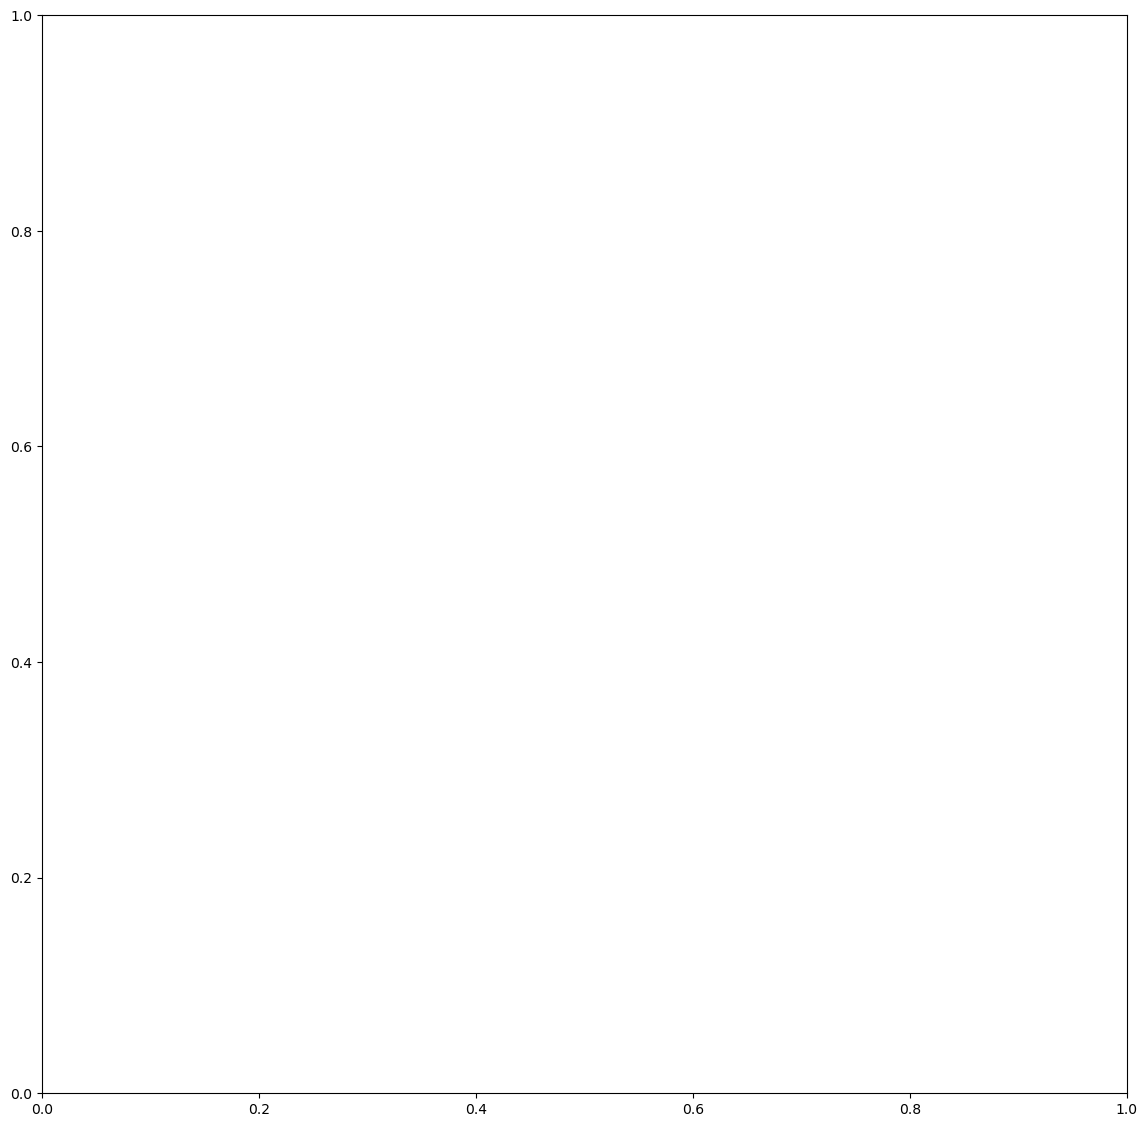

In [42]:
num_columns = 96
start_column_index = 6
end_column_index = start_column_index + num_columns
# Use the actual column names for the 15-min interval data
heatmap_columns = list(traffic_2024_gpd.columns[start_column_index:end_column_index])

start_time = datetime.strptime("00:00:00", "%H:%M:%S")

fig, ax = plt.subplots(figsize=(14, 14))
time_text = ax.text(0.5, 1.02, '', transform=ax.transAxes, ha='center', va='bottom', fontsize=16)

# --- 4. Define the animation function ---
def animate(i):
    ax.cla()  # Clear the previous frame

    # Plot base layers first
    streets_gdf.plot(
        ax=ax, 
        edgecolor='black', 
        linewidth=0.2, 
        label='Street Centerlines'
    )

    # Select the current column for the heatmap
    current_column = heatmap_columns[i]

    # Create the heatmap based on the current column's values
    traffic_2024_gpd.plot(
        column=current_column,
        ax=ax,
        legend=False,
        cmap='YlOrRd',
        markersize=60,
        vmin=20,
        vmax=1000
    )

    current_time = (start_time + timedelta(minutes=15 * i)).time()
    time_str = current_time.strftime("%H:%M:%S")
    time_text = ax.text(0.5, 1.02, f"Time: {time_str}", transform=ax.transAxes, ha='center', va='bottom', fontsize=16)
    # Customize plot appearance
    ax.set_axis_off()

ani = animation.FuncAnimation(fig, animate, frames=num_columns, repeat=False) # Set repeat=True if you want the animation to loop

# --- 6. Save or Display the animation ---
# To save the animation to a file (e.g., GIF or MP4)
# Make sure you have the necessary writers installed (e.g., ImageMagick for GIF, ffmpeg for MP4)
#ani.save('../images/animated_heatmap_2024.gif', writer='imagemagick', fps=4) # Adjust fps as needed

# To display the animation in a Jupyter Notebook or other interactive environment
plt.show() 

In [43]:
charlotte_pk = traffic_2024[traffic_2024['AT_ROAD'].str.contains('CHARLOTTE', na=False)]

In [44]:
charlotte_pk

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_1,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE
1850886,19000584,2-WAY,36.121317,-86.920561,OLD CHARLOTTE PIKE,OLD CHARLOTTE PK.,0.0,0.0,0.0,0.0,...,3.0,2.0,3.0,0.0,5.0,5.0,6.0,1.0,2024-10-03 00:00:00,2024-10-04 00:00:00
1821704,19000059,2-WAY,36.146794,-86.858000,S OF CHARLOTTE AT I-40 W,WHITE BRIDGE RD.,27.0,25.0,26.0,19.0,...,116.0,72.0,74.0,62.0,69.0,43.0,37.0,31.0,2024-08-12 00:00:00,2024-08-13 00:00:00
1822505,19000059_SB,SB,36.146794,-86.858000,S OF CHARLOTTE AT I-40 W,WHITE BRIDGE RD.,13.0,14.0,13.0,10.0,...,46.0,44.0,39.0,27.0,24.0,19.0,13.0,17.0,2024-08-12 00:00:00,2024-08-13 00:00:00
1821729,19000059_NB,NB,36.146794,-86.858000,S OF CHARLOTTE AT I-40 W,WHITE BRIDGE RD.,14.0,11.0,13.0,9.0,...,70.0,28.0,35.0,35.0,45.0,24.0,24.0,14.0,2024-08-12 00:00:00,2024-08-13 00:00:00
1836760,19000465_WB,WB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,23.0,30.0,16.0,4.0,...,72.0,71.0,60.0,52.0,55.0,48.0,39.0,36.0,2024-09-05 00:00:00,2024-09-06 00:00:00
1836757,19000465,2-WAY,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,44.0,45.0,27.0,21.0,...,134.0,132.0,99.0,82.0,91.0,80.0,61.0,59.0,2024-09-05 00:00:00,2024-09-06 00:00:00
1836762,19000465_EB,EB,36.148878,-86.864273,CHARLOTTE AVE - NEAR I-40,CHARLOTTE PK.,21.0,15.0,11.0,17.0,...,62.0,61.0,39.0,30.0,36.0,32.0,22.0,23.0,2024-09-05 00:00:00,2024-09-06 00:00:00
1824378,19000354,2-WAY,36.153105,-86.822099,CHARLOTTE AVE-WEST AT 25TH AVE AT I-40,CHARLOTTE AVE.,58.0,59.0,57.0,36.0,...,160.0,141.0,133.0,134.0,104.0,95.0,93.0,68.0,2024-08-15 00:00:00,2024-08-16 00:00:00
1824417,19000354_EB,EB,36.153105,-86.822099,CHARLOTTE AVE-WEST AT 25TH AVE AT I-40,CHARLOTTE AVE.,24.0,26.0,26.0,18.0,...,81.0,50.0,57.0,58.0,53.0,37.0,44.0,30.0,2024-08-15 00:00:00,2024-08-16 00:00:00
1824424,19000354_WB,WB,36.153105,-86.822099,CHARLOTTE AVE-WEST AT 25TH AVE AT I-40,CHARLOTTE AVE.,34.0,33.0,31.0,18.0,...,79.0,91.0,76.0,76.0,51.0,58.0,49.0,38.0,2024-08-15 00:00:00,2024-08-16 00:00:00


In [45]:
# traffic_2024.to_csv('../data/traffic_2024.csv', index=False)

In [46]:
traffic_2014 = useful_traffic_data[useful_traffic_data['ST_DATE'].str.contains('2014')]

traffic_2014 = traffic_2014.drop('AADT' , axis=1, inplace=False)
traffic_2014 = traffic_2014.drop_duplicates()

traffic_2014_gpd = gpd.GeoDataFrame(traffic_2014, geometry=gpd.points_from_xy(traffic_2014['LONGITUDE'], traffic_2014['LATITUDE']))
traffic_2014_gpd.crs = 'EPSG:4326'  # Set the coordinate reference system


c:\Users\cavin\miniforge3\Lib\site-packages\matplotlib\animation.py:908: UserWarning:

Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.



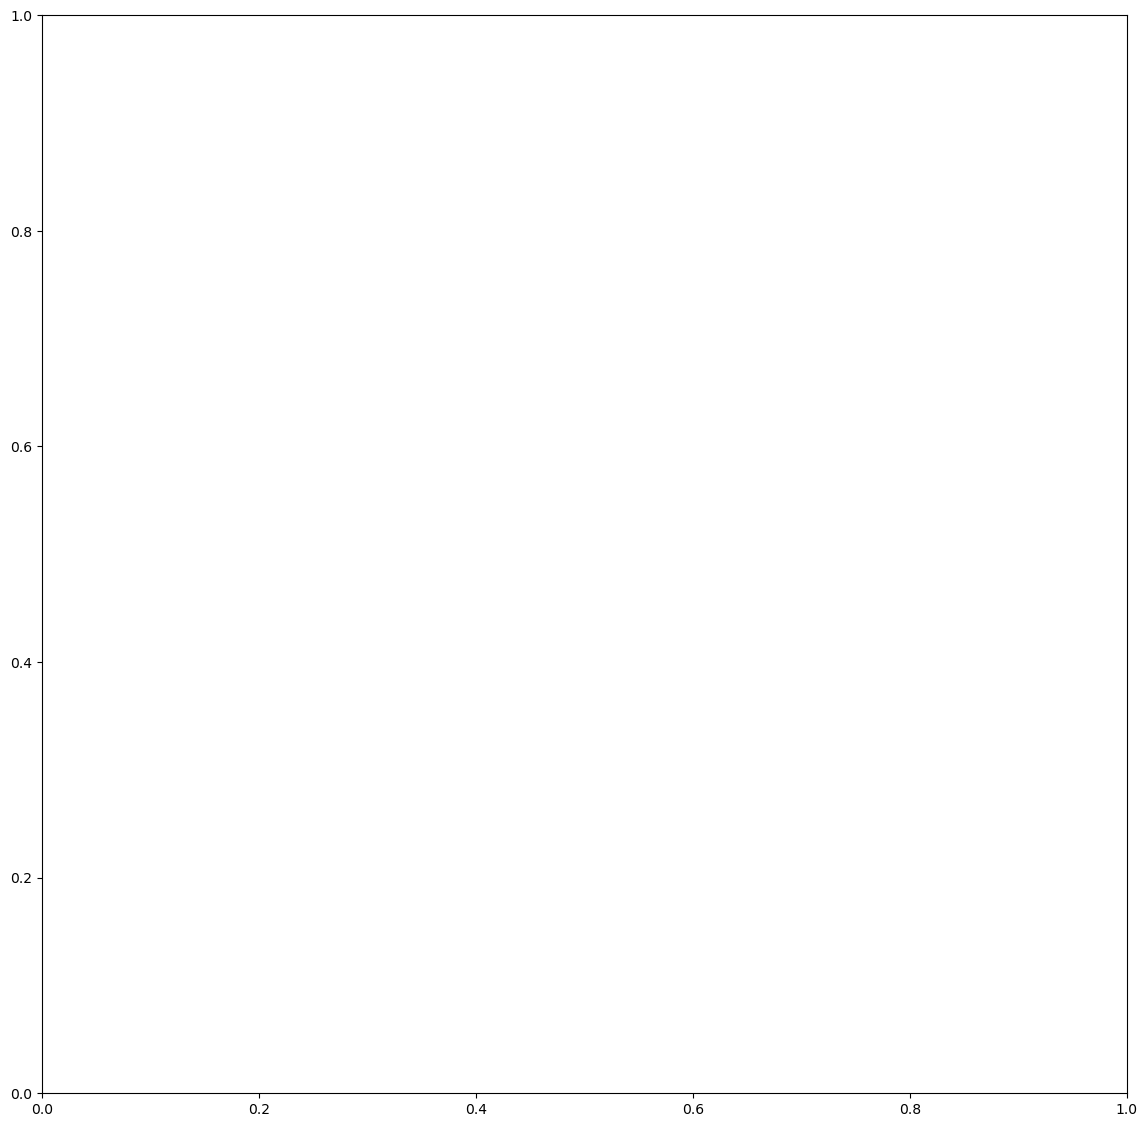

In [47]:
num_columns = 96
start_column_index = 6
end_column_index = start_column_index + num_columns
# Use the actual column names for the 15-min interval data
heatmap_columns = list(traffic_2014_gpd.columns[start_column_index:end_column_index])

start_time = datetime.strptime("00:00:00", "%H:%M:%S")

fig, ax = plt.subplots(figsize=(14, 14))
time_text = ax.text(0.5, 1.02, '', transform=ax.transAxes, ha='center', va='bottom', fontsize=16)

# --- 4. Define the animation function ---
def animate(i):
    ax.cla()  # Clear the previous frame

    # Plot base layers first
    streets_gdf.plot(
        ax=ax, 
        edgecolor='black', 
        linewidth=0.2, 
        label='Street Centerlines'
    )

    # Select the current column for the heatmap
    current_column = heatmap_columns[i]

    # Create the heatmap based on the current column's values
    traffic_2014_gpd.plot(
        column=current_column,
        ax=ax,
        legend=False,
        cmap='YlOrRd',
        markersize=60,
        vmin=10,
        vmax=1000
    )
    current_time = (start_time + timedelta(minutes=15 * i)).time()
    time_str = current_time.strftime("%H:%M:%S")
    time_text = ax.text(0.5, 1.02, f"Time: {time_str}", transform=ax.transAxes, ha='center', va='bottom', fontsize=16)

    # Customize plot appearance
    ax.set_axis_off()

ani = animation.FuncAnimation(fig, animate, frames=num_columns, repeat=False) # Set repeat=True if you want the animation to loop

# --- 6. Save or Display the animation ---
# To save the animation to a file (e.g., GIF or MP4)
# Make sure you have the necessary writers installed (e.g., ImageMagick for GIF, ffmpeg for MP4)
#ani.save('../images/animated_heatmap_2014.gif', writer='imagemagick', fps=4) # Adjust fps as needed

# To display the animation in a Jupyter Notebook or other interactive environment
plt.show() 

In [48]:
stops_df_gdf = gpd.GeoDataFrame(stops_df, geometry=gpd.points_from_xy(stops_df['stop_lon'], stops_df['stop_lat']))
stops_df_gdf.crs = 'EPSG:4326'  # Set the

In [49]:
stops_df_gdf[stops_df_gdf['trip_id'] == 353352]

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry
80684,MCC5_7,353352,1,16:35:00,16:35:00,NaN,CENTRAL 5TH AVE - BAY 7,36.166804,-86.781446,MTAMCC,POINT (-86.78145 36.1668)
80685,6AVDEASN,353352,2,16:37:18,16:37:18,0.3445,6TH AVE & DEADERICK ST SB,36.164830,-86.782945,NaN,POINT (-86.78294 36.16483)
80686,6AVCHUSN,353352,3,16:39:03,16:39:03,0.6066,6TH AVE N & CHURCH ST SB,36.162770,-86.781552,NaN,POINT (-86.78155 36.16277)
80687,8ABROSN,353352,4,16:42:53,16:42:53,1.1785,8TH AVE S & BROADWAY AVE SB,36.159047,-86.782292,NaN,POINT (-86.78229 36.15905)
80688,8ADEMSN,353352,5,16:44:38,16:44:38,1.4403,8TH AVE S & DEMONBREUN ST SB,36.156975,-86.780929,NaN,POINT (-86.78093 36.15698)
80689,LAFEWIEN,353352,6,16:49:19,16:49:19,2.1396,LAFAYETTE ST & EWING AVE SB,36.153330,-86.775805,NaN,POINT (-86.7758 36.15333)
80690,LAF5AEN,353352,7,16:51:00,16:51:00,2.3815,GREYHOUND STATION - LAFAYETTE ST & 5TH AVE S,36.152481,-86.773315,NaN,POINT (-86.77332 36.15248)
80691,LAF1AEM,353352,8,16:55:32,16:55:32,3.1778,LAFAYETTE ST & 1ST AVE S EB,36.149651,-86.765113,NaN,POINT (-86.76511 36.14965)
80692,MXOWHARF,353352,9,16:56:51,16:56:51,3.4103,WHARF STATION OUTBOUND,36.148839,-86.762710,NaN,POINT (-86.76271 36.14884)
80693,LAFFAIEN,353352,10,16:59:22,16:59:22,3.8528,LAFAYETTE ST & FAIRFIELD AVE EB,36.147292,-86.758147,NaN,POINT (-86.75815 36.14729)


In [50]:
stops_df_gdf['departure_time'] = pd.to_datetime(stops_df_gdf['departure_time'], format='%H:%M:%S', errors='coerce').dt.time

In [51]:
trip_avg_df = stops_df_gdf.copy()
trip_avg_df['departure_time_parsed'] = trip_avg_df['departure_time'].apply(lambda x: pd.to_datetime(x, format='%H:%M:%S', errors='coerce'))

first_last = (
    trip_avg_df.sort_values(['trip_id', 'stop_sequence'])
      .groupby('trip_id')
      .agg(
          first_stop_sequence=('stop_sequence', 'first'),
          last_stop_sequence=('stop_sequence', 'last'),
          first_departure=('departure_time_parsed', 'first'),
          last_departure=('departure_time_parsed', 'last')
      )
)

first_last['duration_min'] = (first_last['last_departure'] - first_last['first_departure']).dt.total_seconds() / 60

In [52]:
average_duration = first_last['duration_min'].mean()
print(f"Average trip duration (min): {average_duration:.2f}")

median_duration = first_last['duration_min'].median()
print(f"Median trip duration (min): {median_duration:.2f}")

max_duration = first_last['duration_min'].max()
print(f"Max trip duration (min): {max_duration:.2f}")

max_trip_id = first_last['duration_min'].idxmax()
print(f"Trip ID with max duration: {max_trip_id}")

min_duration = first_last['duration_min'].min()
print(f"Min trip duration (min): {min_duration:.2f}")



Average trip duration (min): 33.48
Median trip duration (min): 32.00
Max trip duration (min): 107.00
Trip ID with max duration: 353352
Min trip duration (min): 0.00


In [53]:
(
stops_df_gdf.groupby('stop_name')
.count()
.sort_values(by='stop_id', ascending=False, inplace=False)
)

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_lat,stop_lon,parent_station,geometry
stop_name,,,,,,,,,,
JAMES ROBERTSON PKWY & 7TH AVE N,995,995,995,995,708,995,995,995,0,995
JAMES ROBERTSON PKWY & 5TH AVE N EB,995,995,995,995,708,995,995,995,0,995
8TH AVE S & BROADWAY AVE NB,963,963,963,963,667,963,963,963,0,963
DR MARTIN LUTHER KING JR BLVD & 7TH AVE N EB,660,660,660,660,473,660,660,660,0,660
CLARKSVILLE PIKE & ED TEMPLE BLVD S,657,657,657,657,493,657,657,657,0,657
...,...,...,...,...,...,...,...,...,...,...
ACORN DR & ELM TREE DR SB,2,2,2,2,0,2,2,2,0,2
MARTIN LUTHER KING SCHOOL,1,1,1,1,0,1,1,1,0,1
JOHN MALLETTE DR & ASHTON AVE WB,1,1,1,1,0,1,1,1,0,1


In [54]:
central_df = stops_df_gdf[stops_df_gdf['parent_station'].str.contains('MTAMCC', na=False)]


In [55]:
stops_df_gdf[stops_df_gdf['stop_name'].str.contains('CHARLOTTE')]

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry
4132,11ACHASF,347773,3,6:17:30,NaT,1.0547,11TH AVE & CHARLOTTE AVE SB,36.161582,-86.790293,NaN,POINT (-86.79029 36.16158)
4161,11ACHASF,347774,3,9:18:00,NaT,1.0547,11TH AVE & CHARLOTTE AVE SB,36.161582,-86.790293,NaN,POINT (-86.79029 36.16158)
4190,11ACHASF,347775,3,9:48:00,NaT,1.0547,11TH AVE & CHARLOTTE AVE SB,36.161582,-86.790293,NaN,POINT (-86.79029 36.16158)
4219,11ACHASF,347776,3,10:18:00,10:18:00,1.0547,11TH AVE & CHARLOTTE AVE SB,36.161582,-86.790293,NaN,POINT (-86.79029 36.16158)
4248,11ACHASF,347777,3,10:48:00,10:48:00,1.0547,11TH AVE & CHARLOTTE AVE SB,36.161582,-86.790293,NaN,POINT (-86.79029 36.16158)
...,...,...,...,...,...,...,...,...,...,...,...
194034,28ACHANF,353068,58,20:01:00,20:01:00,18.6232,28TH AVE & CHARLOTTE AVE NB,36.154331,-86.818228,NaN,POINT (-86.81823 36.15433)
194115,28ACHANF,353069,58,20:45:00,20:45:00,18.6232,28TH AVE & CHARLOTTE AVE NB,36.154331,-86.818228,NaN,POINT (-86.81823 36.15433)
194196,28ACHANF,353070,58,21:30:00,21:30:00,18.6232,28TH AVE & CHARLOTTE AVE NB,36.154331,-86.818228,NaN,POINT (-86.81823 36.15433)
194277,28ACHANF,353071,58,22:15:00,22:15:00,18.6232,28TH AVE & CHARLOTTE AVE NB,36.154331,-86.818228,NaN,POINT (-86.81823 36.15433)


In [56]:
central_df.sample(10)

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry
121910,MCC4_18,351781,1,17:15:00,17:15:00,NaN,CENTRAL 4TH AVE - BAY 18,36.166233,-86.781827,MTAMCC,POINT (-86.78183 36.16623)
42055,MCC4_19,350770,1,18:15:00,18:15:00,NaN,CENTRAL 4TH AVE - BAY 19,36.166581,-86.781917,MTAMCC,POINT (-86.78192 36.16658)
184910,MCC5_9,352392,1,21:15:00,21:15:00,NaN,CENTRAL 5TH AVE - BAY 9,36.166706,-86.781693,MTAMCC,POINT (-86.78169 36.16671)
159876,MCC5_11,349387,20,7:07:00,NaT,4.9944,CENTRAL 5TH AVE - BAY 11,36.166590,-86.781996,MTAMCC,POINT (-86.782 36.16659)
169739,MCC4_19,351001,1,8:15:00,NaT,NaN,CENTRAL 4TH AVE - BAY 19,36.166581,-86.781917,MTAMCC,POINT (-86.78192 36.16658)
99343,MCC4_20,349127,1,13:20:00,13:20:00,NaN,CENTRAL 4TH AVE - BAY 20,36.166545,-86.781895,MTAMCC,POINT (-86.7819 36.16654)
78909,MCC5_7,353171,1,7:30:00,NaT,NaN,CENTRAL 5TH AVE - BAY 7,36.166804,-86.781446,MTAMCC,POINT (-86.78145 36.1668)
124088,MCC4_18,351836,33,16:40:00,16:40:00,17.9312,CENTRAL 4TH AVE - BAY 18,36.166233,-86.781827,MTAMCC,POINT (-86.78183 36.16623)
19943,MCC4_24,348804,28,13:54:00,13:54:00,10.8122,CENTRAL 4TH AVE - BAY 24,36.166751,-86.781412,MTAMCC,POINT (-86.78141 36.16675)
100979,MCC5_2,349292,20,21:37:00,21:37:00,4.9528,CENTRAL 5TH AVE - BAY 2,36.166259,-86.781861,MTAMCC,POINT (-86.78186 36.16626)


In [57]:
#full_traffic_data.groupby('AT_ROAD').sum()

num_frames: 29, x shape: (29,), y shape: (29,)


c:\Users\cavin\miniforge3\Lib\site-packages\matplotlib\animation.py:908: UserWarning:

Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.



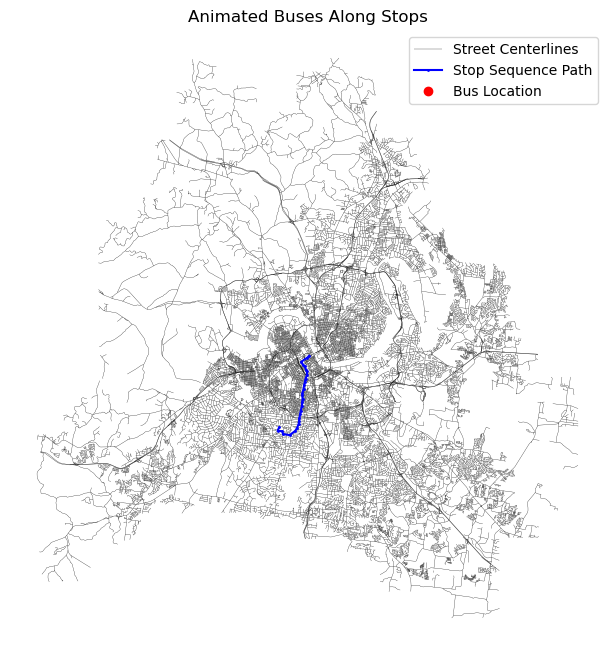

In [58]:
if not stops_df_gdf.empty:
    #trip_id = stops_df_gdf['trip_id'] # Or pick a specific trip_id
    trip_stops = stops_df_gdf[stops_df_gdf['trip_id'] == 347773].sort_values('stop_sequence')

    # Extract coordinates
    x = trip_stops.geometry.x.values
    y = trip_stops.geometry.y.values

    num_frames = min(len(x), len(y))

    print(f"num_frames: {num_frames}, x shape: {x.shape}, y shape: {y.shape}")

    if num_frames == 0:
        print("No stops found for the selected trip_id.")
    else:
        fig, ax = plt.subplots(figsize=(10, 8))

        streets_gdf.plot(ax=ax, edgecolor='black', linewidth=0.2, zorder=0, label='Street Centerlines')
        ax.plot(x, y, 'o-', color='blue', markersize=1, label='Stop Sequence Path', zorder=1)

        point, = ax.plot([], [], 'ro', markersize=6, label='Bus Location', zorder=2)

        ax.set_title(f'Animated Buses Along Stops')
        ax.set_axis_off()
        plt.legend()

        def animate(i):
            point.set_data([x[i]], [y[i]])  # Wrap in list to make it a sequence
            return [point]


        if num_frames > 0:
            ani = animation.FuncAnimation(
                fig, animate, frames=range(num_frames), interval=600, repeat=False
            )

        
#ani.save('../images/bus_animation_12.gif', writer='pillow', fps=4)
plt.show()

<Axes: >

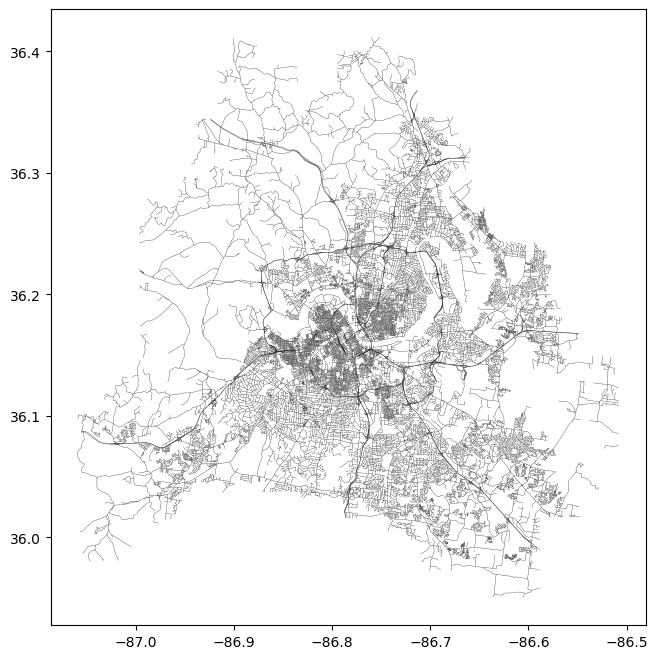

In [59]:
fig, ax = plt.subplots(figsize=(10, 8))

streets_gdf.plot(ax=ax, edgecolor='black', linewidth=0.2, zorder=0, label='Street Centerlines')

In [60]:
pike_data = full_traffic_data[full_traffic_data['AT_ROAD'].str.contains('PIKE' or 'PK', na=False)]

In [61]:
pike_data_gdf = gpd.GeoDataFrame(pike_data, geometry=gpd.points_from_xy(pike_data['LONGITUDE'], pike_data['LATITUDE']))
pike_data_gdf.crs = 'EPSG:4326'

In [62]:
streets_gdf = gpd.GeoDataFrame(streets_gdf, geometry=streets_gdf.geometry.to_crs(epsg=4326))

In [63]:
# Plot street centerlines and highlight intersections with Pike data

# fig, ax = plt.subplots(figsize=(10, 8))

# # Plot all streets
# streets_gdf.plot(ax=ax, edgecolor='black', linewidth=0.2, zorder=0, label='Street Centerlines')

# # Plot Pike data points
# pike_data_gdf.plot(ax=ax, color='green', markersize=8, zorder=1, label='Pike Data Points')

# # Find intersections: buffer Pike points slightly and spatial join with streets
# pike_buffer = pike_data_gdf.copy()
# pike_buffer = pike_buffer.to_crs(epsg=4326)
# intersections = gpd.sjoin(streets_gdf, pike_buffer, how='inner', predicate='intersects')

# # Plot intersections
# intersections.plot(ax=ax, color='red', linewidth=2, zorder=2, label='Intersections')

# ax.set_title('Street Centerlines and Pike Data Intersections')
# ax.set_axis_off()
# plt.legend()
# plt.show()

In [64]:
frequent = routes[routes['route_id'].isin([3, 7, 22, 23, 50, 52, 55, 56])]['route_long_name']

frequent_route_names = frequent.astype(str).tolist()

In [65]:
import re
pattern = '|'.join([re.escape(str(x)) for x in frequent_route_names])

In [66]:
filtered_stops = stops_df_gdf[stops_df_gdf['stop_name'].str.contains(pattern, na=False, case=False)]

In [67]:
unique_trip_ids = stops_df_gdf[stops_df_gdf.index.isin(filtered_stops.index)]['trip_id'].unique().tolist()
print(unique_trip_ids)

[347551, 347552, 347553, 347554, 347555, 347556, 347557, 347558, 347559, 347560, 347561, 347562, 347564, 347566, 347572, 347573, 347574, 347575, 347576, 347577, 347578, 347579, 347580, 347586, 347588, 347590, 347591, 347592, 347593, 347594, 347581, 347582, 347583, 347584, 347585, 347599, 347600, 347601, 347602, 347603, 347604, 347605, 347606, 347607, 347608, 347610, 347612, 347613, 347615, 347619, 347620, 347621, 347622, 347633, 347634, 347636, 347639, 347641, 347642, 347643, 347623, 347624, 347625, 347626, 347627, 347628, 347629, 347630, 347631, 347632, 347773, 347774, 347775, 347776, 347777, 347778, 347779, 347780, 347781, 347782, 347783, 347791, 347792, 347793, 347794, 347795, 347796, 347797, 347798, 347810, 347784, 347785, 347786, 347787, 347788, 347789, 347790, 347799, 347800, 347801, 347802, 347803, 347804, 347805, 347806, 347807, 347808, 347809, 347811, 347812, 347823, 347829, 347830, 347831, 347832, 347833, 347834, 347835, 347836, 347848, 347813, 347814, 347815, 347816, 347817,

In [68]:
trips_that_matter = stops_df_gdf[stops_df_gdf['trip_id'].isin(unique_trip_ids)]

In [69]:
trips_that_matter['departure_time'] = pd.to_timedelta(trips_that_matter['departure_time'].astype(str), errors='coerce')

c:\Users\cavin\miniforge3\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [70]:
trips_that_matter = trips_that_matter[trips_that_matter['departure_time'] > pd.to_timedelta('14:00:00')]

KeyboardInterrupt: 

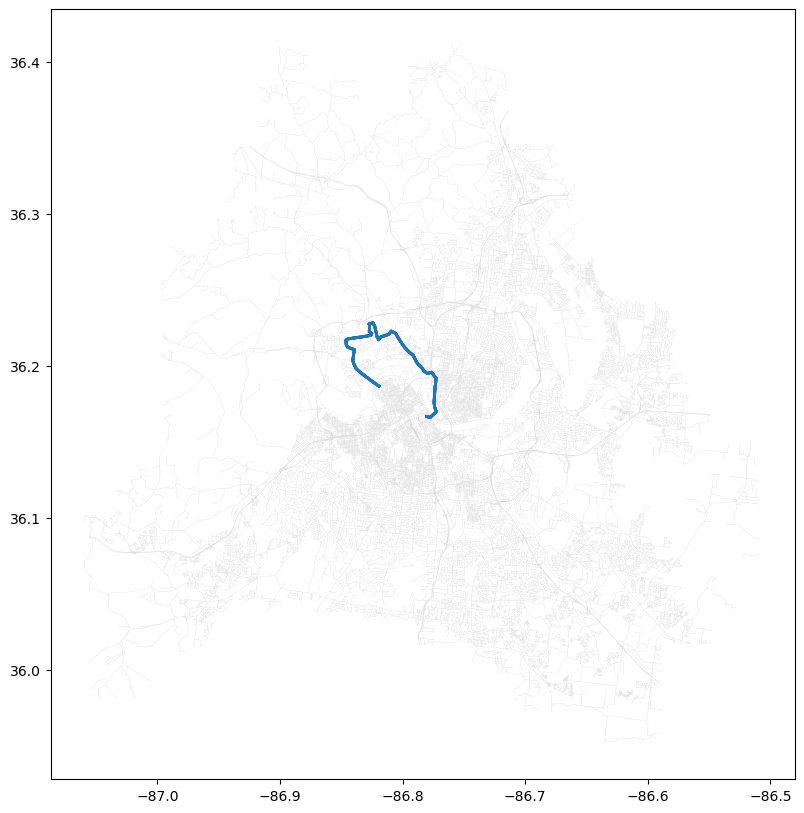

In [71]:
from shapely.geometry import LineString

fig, ax = plt.subplots(figsize=(12, 10))
streets_gdf.plot(ax=ax, edgecolor='lightgray', linewidth=0.2, zorder=0)

for trip_id, group in trips_that_matter.groupby('trip_id'):
    group_sorted = group.sort_values('stop_sequence')
    group_sorted = group_sorted.drop_duplicates(subset='geometry')
    if len(group_sorted) > 1:
        line = LineString(group_sorted.geometry.tolist())
        gpd.GeoSeries([line], crs=group_sorted.crs).plot(ax=ax, linewidth=2, alpha=0.5)

ax.set_title("Frequent Bus Routes in Davidson County")
ax.set_axis_off()
#plt.savefig('../images/frequent_bus_routes_davidson_county.png', bbox_inches='tight', dpi=600)
plt.show()

In [ ]:
traffic_2024_gpd[traffic_2024_gpd['geometry'].isin([trips_that_matter.geometry.y])]

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE,geometry


In [ ]:
on_ramp_df = pd.DataFrame({
    'Year': [2004, 2014, 2024],
    'I-65 North': [6417, 8240, 8915],
    'I-65 South': [21229, 22581, 20768],
    'I-24 West': [6294, 8562, 9523],
    'I-24 East': [6236, 5654, 5712],
    'I-40 West': [6173, 7146, 9356],
    'I-40 East': [3907, 4213, 6400]
})

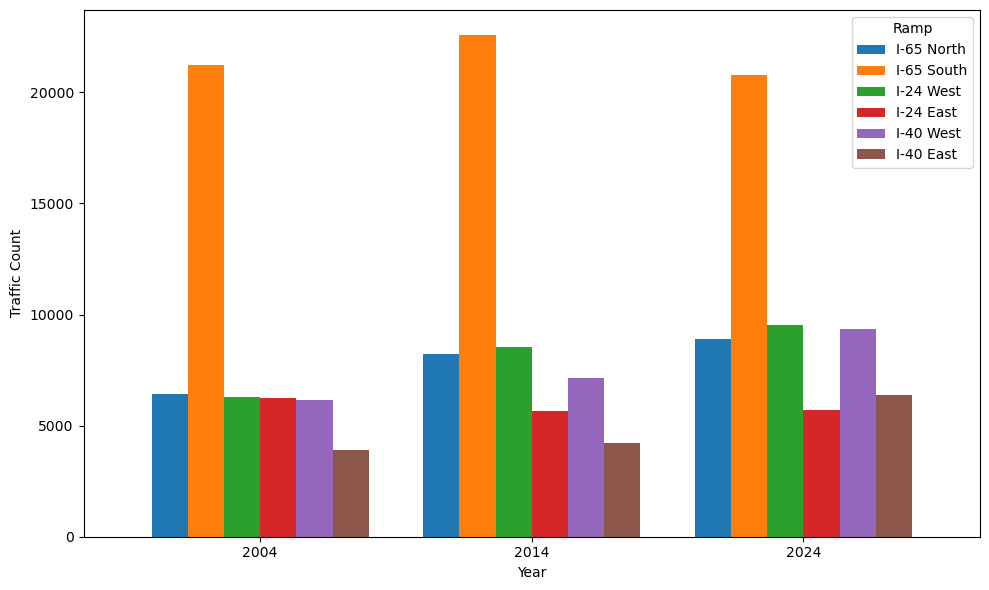

In [ ]:
ax = on_ramp_df.plot(
    x='Year',
    #y=on_ramp_df.columns[6],
    kind='bar',
    figsize=(10, 6),
    width=0.8
)

#plt.title('On-Ramp Traffic Data for Major Highways in Nashville')
plt.xlabel('Year')
plt.ylabel('Traffic Count')
plt.xticks(rotation=0)
plt.legend(title='Ramp')
plt.tight_layout()
plt.show()

In [ ]:
i40_04 = full_traffic_data[
	(full_traffic_data['ON_ROAD_ALIAS'].str.contains('I-40', na=False)) &
	(full_traffic_data['END_DATE'].str.contains('2004'))
]
i40_04 = i40_04.drop('AADT' , axis=1, inplace=False)
i40_04 = i40_04.drop_duplicates()

In [ ]:
i65_04 = full_traffic_data[
	(full_traffic_data['ON_ROAD_ALIAS'].str.contains('65', na=False)) &
	(full_traffic_data['END_DATE'].str.contains('2024'))
]
i65_04 = i65_04.drop('AADT' , axis=1, inplace=False)
i65_04 = i65_04.drop_duplicates()

In [ ]:
i65_04[i65_04['DIR'].str.contains('SB')]

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_1,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE
1782141,19000201_SB,SB,36.201855,-86.776578,S OF TRINITY LN,I-65,284.0,262.0,296.0,238.0,...,612.0,585.0,570.0,581.0,454.0,442.0,405.0,370.0,2024-04-24 00:00:00,2024-04-25 00:00:00
1782157,19000315_SB,SB,36.189113,-86.792409,NASHVILLE,I-65,122.0,114.0,98.0,92.0,...,304.0,303.0,301.0,282.0,188.0,199.0,181.0,155.0,2024-04-24 00:00:00,2024-04-25 00:00:00
1793659,19000214_SB,SB,36.049520,-86.775219,B/T HARDIN PLACE & O.H. BLVD,I-65,177.0,183.0,188.0,143.0,...,411.0,452.0,416.0,365.0,272.0,240.0,220.0,183.0,2024-05-21 00:00:00,2024-05-22 00:00:00
1793947,19000329_SB,SB,36.139232,-86.775943,S OF I-40 LOOP,I-65,138.0,103.0,135.0,120.0,...,473.0,377.0,266.0,303.0,259.0,283.0,205.0,168.0,2024-05-22 00:00:00,2024-05-23 00:00:00


In [ ]:
i65_north_04

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE,AADT
1783063,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6698.0
1783064,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,7054.0
1783065,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6653.0
1783066,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6725.0
1783067,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6582.0
1783068,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,5649.0
1783069,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,5989.0
1783070,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,0.0
1783071,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,7737.0
1783072,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6642.0


In [ ]:
i24_04 = full_traffic_data[
	(full_traffic_data['ON_ROAD_ALIAS'].str.contains('I-24', na=False)) &
	(full_traffic_data['END_DATE'].str.contains('2004'))
]
i24_04 = i24_04.drop('AADT' , axis=1, inplace=False)
i24_04 = i24_04.drop_duplicates()

In [ ]:
i24_04[i24_04['LOCAL_ID'].str.contains('79_EB')]

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE,AADT
1875848,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-19 00:00:00,2024-11-20 00:00:00,25890.0
1875849,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-19 00:00:00,2024-11-20 00:00:00,25087.0
1875850,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-19 00:00:00,2024-11-20 00:00:00,27044.0
1875851,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-19 00:00:00,2024-11-20 00:00:00,26692.0
1875852,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-19 00:00:00,2024-11-20 00:00:00,28427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1882307,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-07 00:00:00,2024-12-08 00:00:00,25890.0
1882308,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-07 00:00:00,2024-12-08 00:00:00,25087.0
1882309,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-07 00:00:00,2024-12-08 00:00:00,27044.0
1882310,79_EB,EB,36.339473,-86.917087,NEAR CHEATHAM CO LINE,I-24,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-07 00:00:00,2024-12-08 00:00:00,26692.0


In [ ]:
i65_north_04[i65_north_04['DIR'].str.contains('RAMP')]

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,H01_1,H01_2,H01_3,H01_4,...,H23_2,H23_3,H23_4,H24_1,H24_2,H24_3,H24_4,ST_DATE,END_DATE,AADT
1783063,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6698.0
1783064,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,7054.0
1783065,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6653.0
1783066,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6725.0
1783067,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6582.0
1783068,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,5649.0
1783069,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,5989.0
1783070,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,0.0
1783071,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,7737.0
1783072,19000236R,RAMP,36.322356,-86.704903,0097D,I-65,24.0,28.0,29.0,30.0,...,33.0,22.0,33.0,19.0,24.0,28.0,22.0,2024-04-25 00:00:00,2024-04-26 00:00:00,6642.0


In [ ]:
i65_south_04 = i65_04[i65_04['LOCAL_ID'].str.contains('19000219R')]
i65_south_04.iloc[:, 6:96].sum(axis=1)

80229    20968.0
dtype: float64

In [ ]:
i24_north_04 = i24_04[i24_04['LOCAL_ID'].str.contains('19000652')]
i24_north_04.iloc[:, 6:96].sum(axis=1)

Series([], dtype: float64)

In [ ]:

i40_04.iloc[:, 6:96].sum(axis=1)

60633    23991.0
60839    26323.0
60873     9401.0
60924     9962.0
61983    11351.0
          ...   
81102    11101.0
81136     3818.0
81137    11301.0
81171     1233.0
81260     8905.0
Length: 62, dtype: float64

In [72]:
lateness_df = pd.read_csv('../data/Wego_regularization.csv')

In [96]:
lateness_df[['TRIP_ID', 'ROUTE_STOP_SEQUENCE', 'ADJUSTED_LATE_COUNT']]

,TRIP_ID,ROUTE_STOP_SEQUENCE,ADJUSTED_LATE_COUNT
0,345106,5.0,0
1,345107,5.0,0
2,345108,5.0,0
3,345110,5.0,0
4,345111,5.0,0
...,...,...,...
62755,353529,4.0,0
62756,353530,4.0,0
62757,353531,4.0,1
62758,353532,4.0,1


In [106]:
matter_lateness = trips_that_matter.merge(lateness_df[['TRIP_ID', 'ROUTE_STOP_SEQUENCE', 'ADJUSTED_LATE_COUNT']], left_on=['trip_id', 'stop_sequence'],right_on=['TRIP_ID','ROUTE_STOP_SEQUENCE'], how='left').drop(['ROUTE_STOP_SEQUENCE', 'TRIP_ID'], axis=1)

In [107]:
matter_lateness

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry,ADJUSTED_LATE_COUNT
0,MCC5_8,347572,1,15:55:00,0 days 15:55:00,NaN,CENTRAL 5TH AVE - BAY 8,36.166768,-86.781424,MTAMCC,POINT (-86.78142 36.16677),NaN
1,UNI2AEF,347572,2,15:58:05,0 days 15:58:05,1.0699,UNION ST & 2ND AVE EB,36.166036,-86.777419,NaN,POINT (-86.77742 36.16604),NaN
2,1SWOONM,347572,3,16:00:05,0 days 16:00:05,1.7638,S 1ST ST & WOODLAND ST NB,36.169739,-86.772489,NaN,POINT (-86.77249 36.16974),NaN
3,1SJAMNM,347572,4,16:01:05,0 days 16:01:05,2.1112,N 1ST ST & JAMES ROBERTSON PKWY NB,36.172643,-86.773761,NaN,POINT (-86.77376 36.17264),NaN
4,N1SOLDNM,347572,5,16:02:00,0 days 16:02:00,2.4281,N 1ST ST & OLDHAM ST NB,36.175433,-86.774320,NaN,POINT (-86.77432 36.17543),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
90501,COUHYDWF,353072,77,23:19:39,0 days 23:19:39,26.5842,COUNTY HOSPITAL RD & HYDES FERRY RD WB,36.189334,-86.838008,NaN,POINT (-86.83801 36.18933),NaN
90502,COUPANWN,353072,78,23:21:17,0 days 23:21:17,27.2918,COUNTY HOSPITAL RD & PANORAMA DR WB,36.184440,-86.843029,NaN,POINT (-86.84303 36.18444),NaN
90503,COUHOSWN,353072,79,23:22:00,0 days 23:22:00,27.6017,COUNTY HOSPITAL RD & HOSPITAL LN WB,36.182700,-86.845591,NaN,POINT (-86.84559 36.1827),NaN
90504,CAMCOUSF,353072,80,23:22:30,0 days 23:22:30,27.8209,CAMILLA CALDWELL LN & COUNTY HOSPITAL RD SB,36.182449,-86.847812,NaN,POINT (-86.84781 36.18245),NaN


In [ ]:

matter_lateness.groupby('trip_id')['ADJUSTED_LATE_COUNT'].sum().sort_values(ascending=False)

trip_id
352315    36.0
352180    35.0
352515    35.0
352688    34.0
352616    33.0
          ... 
349847     0.0
349846     0.0
349845     0.0
349844     0.0
353780     0.0
Name: ADJUSTED_LATE_COUNT, Length: 2024, dtype: float64

In [109]:
matter_lateness['stop_sequence'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86], dtype=int64)

In [108]:
matter_lateness[matter_lateness['ADJUSTED_LATE_COUNT'] > 0]

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry,ADJUSTED_LATE_COUNT
658,DICRICNN,347593,10,15:05:17,0 days 15:05:17,4.2622,DICKERSON PIKE & RICHARDSON AVE NB,36.191684,-86.772668,NaN,POINT (-86.77267 36.19168),1.0
712,DICGRANN,347594,6,15:33:33,0 days 15:33:33,3.2891,DICKERSON PIKE & GRACE ST NB,36.183055,-86.773789,NaN,POINT (-86.77379 36.18306),1.0
1301,FAICLAWF,347641,10,14:29:28,0 days 14:29:28,3.7775,FAIRVIEW DR & CLARKSVILLE PK WB,36.211217,-86.839784,NaN,POINT (-86.83978 36.21122),1.0
1359,CLAASHNF,347642,6,14:56:21,0 days 14:56:21,2.2313,CLARKSVILLE PIKE & ASHLAND CITY HWY NB,36.198551,-86.837911,NaN,POINT (-86.83791 36.19855),1.0
1423,FAICLAWF,347643,10,15:29:28,0 days 15:29:28,3.7775,FAIRVIEW DR & CLARKSVILLE PK WB,36.211217,-86.839784,NaN,POINT (-86.83978 36.21122),1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
90429,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90431,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90432,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90433,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0


In [118]:
traffic_2023 = full_traffic_data[full_traffic_data['END_DATE'].str.contains('2023')]

In [135]:
useful_traffic_2023 = traffic_2023[traffic_2023['H01_1'] > 0].drop('AADT' , axis=1, inplace=False)

In [136]:
useful_traffic_2023_gdf = gpd.GeoDataFrame(
    useful_traffic_2023,
    geometry=gpd.points_from_xy(useful_traffic_2023['LONGITUDE'], useful_traffic_2023['LATITUDE']),
    crs='EPSG:4326'
)

useful_traffic_2023_gdf = useful_traffic_2023_gdf.to_crs(epsg=32616)
matter_lateness_proj = matter_lateness.to_crs(epsg=32616)

buffer_union = matter_lateness_proj.geometry.buffer(25).union_all()

useful_traffic_2023_near_matter = useful_traffic_2023_gdf[useful_traffic_2023_gdf.geometry.within(buffer_union)]

useful_traffic_2023_near_matter = useful_traffic_2023_near_matter.to_crs(epsg=4326)

In [138]:
interval_cols = useful_traffic_2023_near_matter.columns[6:102]

pivoted = useful_traffic_2023_near_matter.melt(
    id_vars=[col for col in useful_traffic_2023_near_matter.columns if col not in interval_cols],
    value_vars=interval_cols,
    var_name='interval',
    value_name='volume'
)

interval_index = pivoted['interval'].apply(lambda x: list(interval_cols).index(x))
pivoted['timedelta'] = pd.to_timedelta(interval_index * 15, unit='m')

useful_2023_pivoted = pivoted.drop_duplicates()

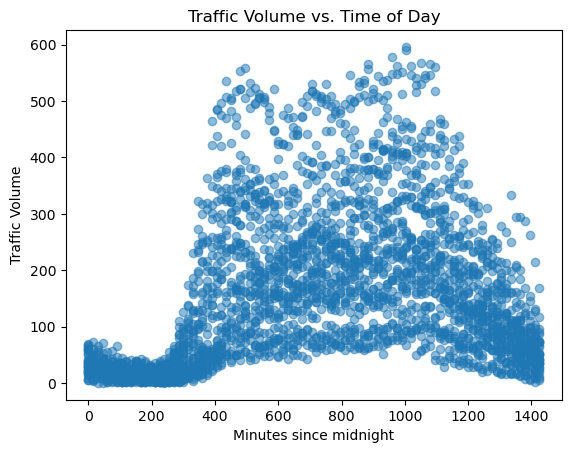

In [ ]:

timedelta_minutes = useful_2023_pivoted['timedelta'].dt.total_seconds() / 60
plt.scatter(timedelta_minutes, useful_2023_pivoted['volume'], alpha=0.5)
plt.xlabel('Minutes since midnight')
plt.ylabel('Traffic Volume')
plt.title('Traffic Volume vs. Time of Day')
#plt.savefig('../images/traffic_volume_vs_time_of_day.png', bbox_inches='tight', dpi=600)
plt.show()

In [139]:
useful_2023_pivoted

,LOCAL_ID,DIR,LATITUDE,LONGITUDE,AT_ROAD,ON_ROAD_ALIAS,ST_DATE,END_DATE,geometry,interval,volume,timedelta
0,19000379,2-WAY,36.204204,-86.729049,MCGAVOCK PK- E OF GALLATIN PIKE,MCGAVOCK PK.,2023-06-08 00:00:00,2023-06-09 00:00:00,POINT (-86.72905 36.2042),H01_1,25.0,0 days 00:00:00
40,19000608,2-WAY,36.101381,-86.802743,SHACKLEFORD RD,SHACKLEFORD RD.,2023-06-12 00:00:00,2023-06-13 00:00:00,POINT (-86.80274 36.10138),H01_1,6.0,0 days 00:00:00
64,19000044,2-WAY,36.204488,-86.747641,E. TRINITY LANE - NASHVILLE,E. TRINITY LN.,2023-06-12 00:00:00,2023-06-13 00:00:00,POINT (-86.74764 36.20449),H01_1,37.0,0 days 00:00:00
104,19000491,2-WAY,36.143970,-86.798941,EDGE HILL AVE - E OF SR-106,EDGEHILL AVE.,2023-06-13 00:00:00,2023-06-14 00:00:00,POINT (-86.79894 36.14397),H01_1,9.0,0 days 00:00:00
137,19000069_WB,WB,36.151524,-86.799044,NEAR JCT SR-106 & SR-1 WESTEND,WEST END AVE.,2023-06-20 00:00:00,2023-06-21 00:00:00,POINT (-86.79904 36.15152),H01_1,29.0,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
59315,19000165_EB,EB,36.138650,-86.819866,WESTEND AVE-B/T FAIRFAX & ACKLEN,WEST END AVE.,2023-09-11 00:00:00,2023-09-12 00:00:00,POINT (-86.81987 36.13865),H24_4,28.0,0 days 23:45:00
59363,19000165_WB,WB,36.138650,-86.819866,WESTEND AVE-B/T FAIRFAX & ACKLEN,WEST END AVE.,2023-09-11 00:00:00,2023-09-12 00:00:00,POINT (-86.81987 36.13865),H24_4,40.0,0 days 23:45:00
59370,19000107,2-WAY,36.111187,-86.749180,THOMPSON LN-W OF NOLENSVILLE RD,THOMPSON LN.,2023-10-05 00:00:00,2023-10-06 00:00:00,POINT (-86.74918 36.11119),H24_4,52.0,0 days 23:45:00
59410,19000107_WB,WB,36.111187,-86.749180,THOMPSON LN-W OF NOLENSVILLE RD,THOMPSON LN.,2023-10-05 00:00:00,2023-10-06 00:00:00,POINT (-86.74918 36.11119),H24_4,19.0,0 days 23:45:00


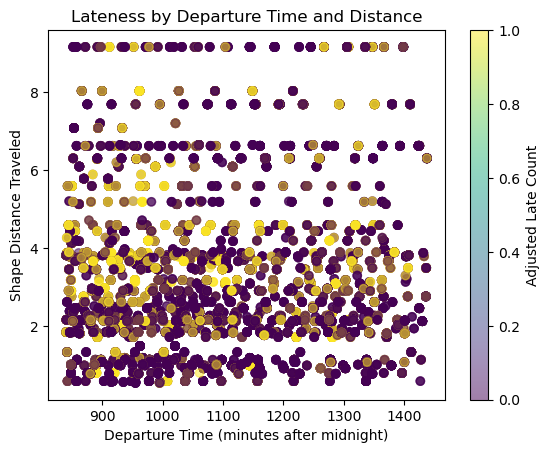

In [121]:
# Convert departure_time (timedelta) to minutes for plotting
departure_minutes = matter_lateness['departure_time'].dt.total_seconds() / 60

plt.scatter(
	departure_minutes,
	matter_lateness['shape_dist_traveled'],
	c=matter_lateness['ADJUSTED_LATE_COUNT'],
	cmap='viridis',
	alpha=0.5
)
plt.xlabel('Departure Time (minutes after midnight)')
plt.ylabel('Shape Distance Traveled')
plt.title('Lateness by Departure Time and Distance')
plt.colorbar(label='Adjusted Late Count')
plt.show()

In [145]:
bus_lateness = matter_lateness[matter_lateness['ADJUSTED_LATE_COUNT'] >= 0]

In [146]:
bus_lateness

,stop_id,trip_id,stop_sequence,arrival_time,departure_time,shape_dist_traveled,stop_name,stop_lat,stop_lon,parent_station,geometry,ADJUSTED_LATE_COUNT
536,DICRICNN,347591,10,14:04:17,0 days 14:04:17,4.2622,DICKERSON PIKE & RICHARDSON AVE NB,36.191684,-86.772668,NaN,POINT (-86.77267 36.19168),0.0
537,DICRICNN,347591,10,14:04:17,0 days 14:04:17,4.2622,DICKERSON PIKE & RICHARDSON AVE NB,36.191684,-86.772668,NaN,POINT (-86.77267 36.19168),0.0
538,DICRICNN,347591,10,14:04:17,0 days 14:04:17,4.2622,DICKERSON PIKE & RICHARDSON AVE NB,36.191684,-86.772668,NaN,POINT (-86.77267 36.19168),0.0
592,DICGRANN,347592,6,14:33:33,0 days 14:33:33,3.2891,DICKERSON PIKE & GRACE ST NB,36.183055,-86.773789,NaN,POINT (-86.77379 36.18306),0.0
593,DICGRANN,347592,6,14:33:33,0 days 14:33:33,3.2891,DICKERSON PIKE & GRACE ST NB,36.183055,-86.773789,NaN,POINT (-86.77379 36.18306),0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
90432,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90433,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90434,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),1.0
90435,ETHBROSF,353072,12,22:23:40,0 days 22:23:40,2.8959,E THOMPSON LN & BROWNING RD SB,36.120599,-86.718195,NaN,POINT (-86.7182 36.1206),0.0


Correlation between traffic volume and bus lateness: 0.483


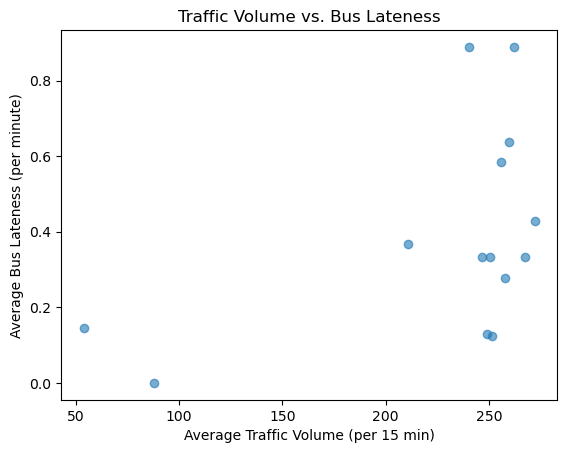

In [156]:
traffic_series = useful_2023_pivoted.groupby('timedelta')['volume'].mean().sort_index()

lateness_series = bus_lateness.groupby('departure_time')['ADJUSTED_LATE_COUNT'].mean().sort_index()

combined = pd.DataFrame({
    'traffic_volume': traffic_series,
    'bus_lateness': lateness_series
}).dropna()

correlation = combined['traffic_volume'].corr(combined['bus_lateness'])
print(f"Correlation between traffic volume and bus lateness: {correlation:.3f}")

plt.scatter(combined['traffic_volume'], combined['bus_lateness'], alpha=0.6)
plt.xlabel('Average Traffic Volume (per 15 min)')
plt.ylabel('Average Bus Lateness (per minute)')
plt.title('Traffic Volume vs. Bus Lateness')
#plt.savefig('../images/traffic_volume_vs_bus_lateness.png', bbox_inches='tight', dpi=600)
plt.show()